C:\Users\lenovo\anaconda3\Lib\site-packages\sklearn\cluster\_agglomerative.py:1006: FutureWarning: Attribute `affinity` was deprecated in version 1.2 and will be removed in 1.4. Use `metric` instead
  warnings.warn(


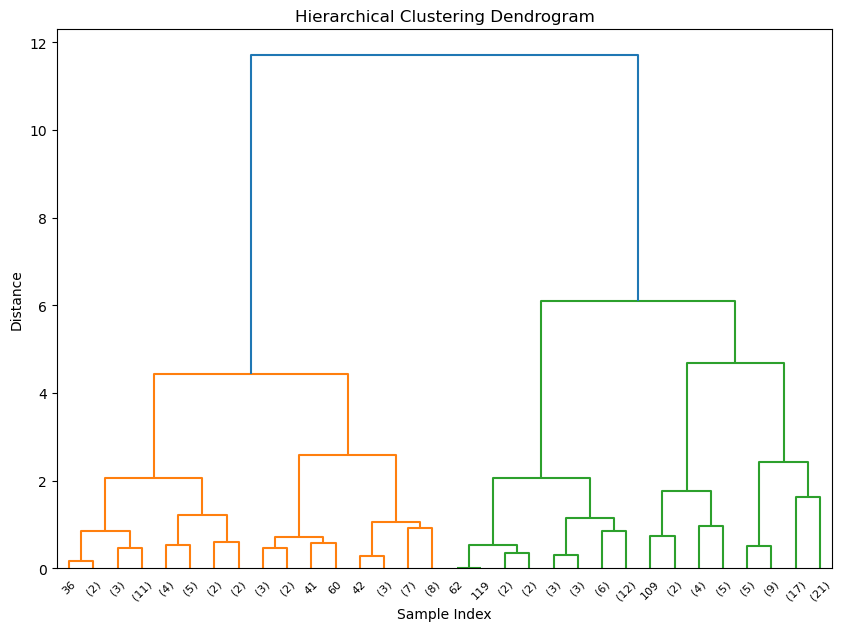

Cluster labels: [1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 0 0 0 2 0 2 0 1 0 1 1 0 2 0 2 0 2 2 2 2 0 0 2 0
 0 0 0 0 0 2 2 2 2 0 2 0 0 2 2 2 2 0 2 1 2 2 2 0 1 2 0 2 0 0 0 0 1 0 0 0 0
 0 0 2 2 0 0 0 0 2 0 2 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 2 0 0 0 2 0
 0 0]


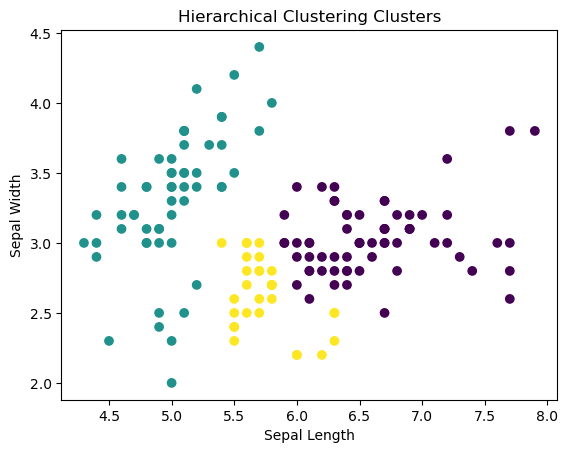

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage

# Load the Iris dataset
iris = load_iris()
X = iris.data[:, :2]  # we only take the first two features.
y = iris.target

# Perform Hierarchical Clustering
hc = AgglomerativeClustering(n_clusters=3, affinity='euclidean', linkage='ward')
hc.fit(X)

# Get the dendrogram
Z = linkage(X, method='ward')
plt.figure(figsize=(10, 7))
dendrogram(Z, truncate_mode='level', p=4)
plt.title('Hierarchical Clustering Dendrogram')
plt.xlabel('Sample Index')
plt.ylabel('Distance')
plt.show()

# Get the cluster labels
labels = hc.labels_

# Print the cluster labels
print("Cluster labels:", labels)

# Plot the clusters
plt.scatter(X[:, 0], X[:, 1], c=labels)
plt.xlabel('Sepal Length')
plt.ylabel('Sepal Width')
plt.title('Hierarchical Clustering Clusters')
plt.show()

C:\Users\lenovo\anaconda3\Lib\site-packages\sklearn\cluster\_agglomerative.py:1006: FutureWarning: Attribute `affinity` was deprecated in version 1.2 and will be removed in 1.4. Use `metric` instead
  warnings.warn(


SSE loss: [20.56859375 19.13928571  3.63333333]
Average linkage criterion: [0.67085589 0.70150348 0.41881313]


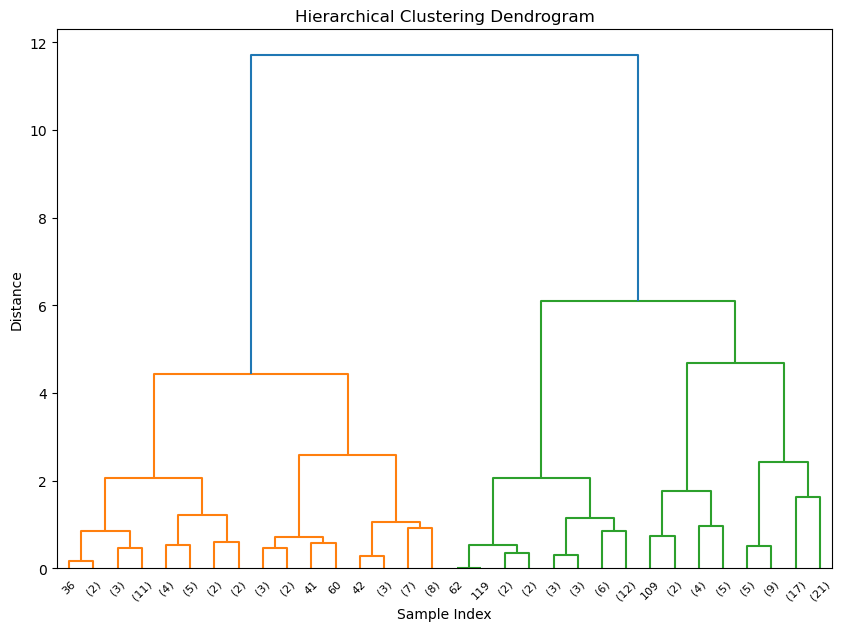

Cluster labels: [1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 0 0 0 2 0 2 0 1 0 1 1 0 2 0 2 0 2 2 2 2 0 0 2 0
 0 0 0 0 0 2 2 2 2 0 2 0 0 2 2 2 2 0 2 1 2 2 2 0 1 2 0 2 0 0 0 0 1 0 0 0 0
 0 0 2 2 0 0 0 0 2 0 2 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 2 0 0 0 2 0
 0 0]


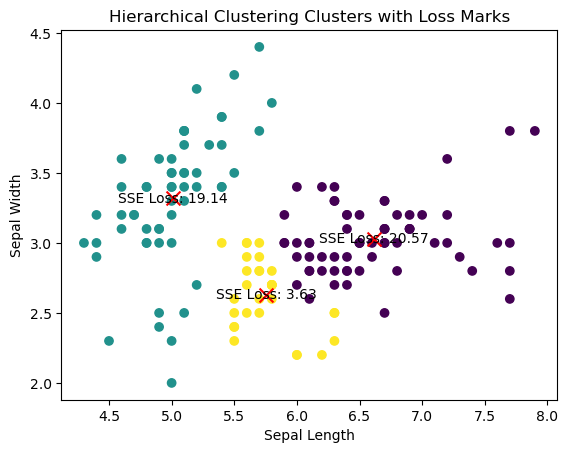

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.metrics.pairwise import pairwise_distances

# Load the Iris dataset
iris = load_iris()
X = iris.data[:, :2]  # we only take the first two features.
y = iris.target

# Perform Hierarchical Clustering
hc = AgglomerativeClustering(n_clusters=3, affinity='euclidean', linkage='ward')
hc.fit(X)

# Calculate the distance matrix
dist_matrix = pairwise_distances(X)

# Calculate the SSE loss
sse_loss = np.zeros((hc.n_clusters,))
for i in range(hc.n_clusters):
    cluster_indices = np.where(hc.labels_ == i)[0]
    cluster_center = np.mean(X[cluster_indices], axis=0)
    sse_loss[i] = np.sum((X[cluster_indices] - cluster_center) ** 2)

# Calculate the average linkage criterion
avg_linkage_criterion = np.zeros((hc.n_clusters,))
for i in range(hc.n_clusters):
    cluster_indices = np.where(hc.labels_ == i)[0]
    avg_linkage_criterion[i] = np.mean(dist_matrix[cluster_indices, :][:, cluster_indices])

# Print the loss functions
print("SSE loss:", sse_loss)
print("Average linkage criterion:", avg_linkage_criterion)

# Get the dendrogram
Z = linkage(X, method='ward')
plt.figure(figsize=(10, 7))
dendrogram(Z, truncate_mode='level', p=4)
plt.title('Hierarchical Clustering Dendrogram')
plt.xlabel('Sample Index')
plt.ylabel('Distance')
plt.show()

# Get the cluster labels
labels = hc.labels_

# Print the cluster labels
print("Cluster labels:", labels)

# Plot the clusters with loss marks
plt.scatter(X[:, 0], X[:, 1], c=labels)
for i in range(hc.n_clusters):
    cluster_indices = np.where(hc.labels_ == i)[0]
    cluster_center = np.mean(X[cluster_indices], axis=0)
    plt.scatter(cluster_center[0], cluster_center[1], marker='x', c='r', s=100)
    plt.text(cluster_center[0], cluster_center[1], f"SSE Loss: {sse_loss[i]:.2f}", ha='center', va='center')
plt.xlabel('Sepal Length')
plt.ylabel('Sepal Width')
plt.title('Hierarchical Clustering Clusters with Loss Marks')
plt.show()

In [3]:
from sklearn.metrics import accuracy_score

# Get the predicted cluster labels
labels_pred = hc.labels_

# Get the true cluster labels
labels_true = y

# Calculate the accuracy
accuracy = accuracy_score(labels_true, labels_pred)*100

print("Accuracy:", accuracy)

Accuracy: 8.0
